# Pre Proccess

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


models_scores_path = "C:\\Users\\matan\\master_thesis\\rl_envs\\procgen\\results\\simple_eval100.csv" #"../../results/models_results.csv"
models_scores = pd.read_csv(models_scores_path)
models_mean_scores = models_scores.groupby('model_index')['total_reward'].mean()
models_mean_dict = {str(k): v for k, v in models_mean_scores.to_dict().items()}

user_question_mapping = {
    'Q205_1': "The explanations of the agent's paths were clear and easy to understand",
    'Q205_3': "The explanations felt too detailed and overwhelming",
    'Q205_4': "The explanations helped me see how my feedback changed the agent's behavior",
    'Q205_5':"The visual demonstrations of policy changes helped me understand the differences between agents",
    'Q205_6': "My feedback helped improve the agent's performance",
    "ai:": "How familiar are you with Artificial Intelligence?",
    "AI_1": "I believe AI will improve my life",
    "AI_2": "I believe that AI will improve my work",
    "AI_3": "I think I will use AI technology in the future",
    "AI_4": "I think AI technology is a threat to humans",
    "AI_5": "I think AI technology is positive for humanity",
}

minigrid_user_results = pd.read_csv('user_results_for_combined_minigrid_df.csv')
fruitbot_user_results = pd.read_csv('user_results_for_combined_fruitbot_df.csv')

# choices_results = pd.read_csv('choices_final_results.csv')

In [2]:
user_results = pd.concat([
    minigrid_user_results.assign(environment='minigrid'),
    fruitbot_user_results.assign(environment='fruitbot')
], ignore_index=True)

user_results.columns

Index(['user_id', 'group', 'trust_the_agent', 'number_of_choices',
       'final_agent_mean_score', 'user_performance', 'age', 'gender',
       'education', 'familiar_with_AI', 'evaluate_final_agent', 'AI_1',
       'ES_understandable', 'AI_2', 'SS_2', 'AI_3', 'ES_overwhelming', 'AI_4',
       'ES_feedback_related', 'AI_5', 'ES_helpful', 'group_label',
       'final_agent', 'mean_good_choice_local', 'mean_good_choice_global',
       'mean_good_choice_demo', 'environment', 'ES_improvement',
       'mean_agent_rating', 'final_score', 'ES_combined'],
      dtype='object')

In [6]:
user_results['group_label'].value_counts()

group_label
Random              126
Control             122
Same                117
Contrast             73
Salient-Contrast     56
Similar              33
Name: count, dtype: int64

In [79]:
choices_results.columns

Index(['user_id', 'episode_index', 'group', 'prev_agent', 'updated_agent',
       'choice', 'good_choice_local', 'good_choice_global', 'good_choice_demo',
       'final_agent', 'feedback_config', 'feedback_level',
       'demonstration_config', 'demonstration_level', 'demo_prev_score',
       'demo_updated_score', 'feedback_count', 'feedback_correctness',
       'agent_rating', 'trust_the_agent', 'choice_time', 'group_label',
       'improved_from_prev_feedback', 'improved_from_prev_mean'],
      dtype='object')

In [144]:
user_results['group'].value_counts()

group
2    8
0    7
4    7
3    7
1    3
Name: count, dtype: int64

# Plotting

In [80]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import mannwhitneyu, f_oneway, kruskal
import itertools, warnings
warnings.filterwarnings("ignore")
%matplotlib inline


In [81]:
# helper functions: plot_barplot, mannwhitneyu_test, anova_test

colors_palette = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']
group_names = ['Control', 'Same', 'Similar', 'Contrast', 'Random']

def plot_barplot(df, x_col, y_col, hue=None, hue_names=None, x_val_names=None,
                 figsize=(6, 5), estimator=lambda x: np.mean(x) * 100, errorbar=('ci', 95),
                 palette=None, x_label='Group', y_label='%', order=None,
                 bar_label_fmt='%.1f%%', ylim_bottom=0, title=None):
    if order is None:
        order = sorted(list(df[x_col].unique()))
    plt.figure(figsize=figsize)
    ax = sns.barplot(data=df, x=x_col, y=y_col, hue=hue, estimator=estimator,
                     errorbar=errorbar, palette=palette, order=order)
    for c in ax.containers:
        ax.bar_label(c, fmt=bar_label_fmt, label_type='edge', fontsize=13)
    x_val_names = x_val_names or [str(l) for l in order]
    ax.set_xticklabels(x_val_names, rotation=(40 if len(x_val_names[0]) > 15 else 0),
                       ha=('right' if len(x_val_names[0]) > 15 else 'center'), fontsize=13)
    if x_label: plt.xlabel(x_label, fontsize=14)
    if y_label: plt.ylabel(y_label, fontsize=14)
    plt.yticks(fontsize=13)
    if hue:
        handles, labels = ax.get_legend_handles_labels()
        display_labels = [hue_names.get(l, l) for l in labels] if isinstance(hue_names, dict) else hue_names
        ax.legend(handles=handles, labels=display_labels, fontsize=13)
    plt.ylim(bottom=ylim_bottom)
    if title:
        plt.title(title, fontsize=14)
    plt.tight_layout()
    plt.show()

def mannwhitneyu_test(df, y_col, x_col, test_type='two-sided'):
    levels = sorted(df[x_col].unique())
    rows = []
    for a, b in itertools.combinations(levels, 2):
        g1, g2 = df[df[x_col]==a][y_col].dropna(), df[df[x_col]==b][y_col].dropna()
        u, p = mannwhitneyu(g1, g2, alternative=test_type)
        rows.append({'group_1': a, 'group_2': b, 'U': u, 'p': round(p, 4)})
    print(pd.DataFrame(rows).to_string(index=False))

def anova_test(df, y_col, x_col):
    groups = [g[y_col].dropna().values for _, g in df.groupby(x_col)]
    f, pf = f_oneway(*groups)
    h, pk = kruskal(*groups)
    print(f"ANOVA F={f:.4f}, p={pf:.4f}  |  Kruskal-Wallis H={h:.4f}, p={pk:.4f}")

In [82]:
# # Map group labels on choices_results
# _gm = {"1":"Same","2":"Similar","3":"Contrast","4":"Random"}
# choices_results['group_label'] = choices_results['group'].astype(str).map(_gm)

# # Did the updated agent improve over prev on the feedback level?
# def _improved_fb(row):
#     try:
#         fc, fl = str(int(row['feedback_config'])), str(int(row['feedback_level']))
#     except:
#         return None
#     ms = models_scores
#     prev = ms[(ms['config_index'].astype(str)==fc)&(ms['start_level'].astype(str)==fl)&(ms['model_index'].astype(str)==str(row['prev_agent']))]['total_reward'].values
#     upd  = ms[(ms['config_index'].astype(str)==fc)&(ms['start_level'].astype(str)==fl)&(ms['model_index'].astype(str)==str(row['updated_agent']))]['total_reward'].values
#     return int(upd[0] > prev[0]) if len(prev) > 0 and len(upd) > 0 else None

# choices_results['improved_from_prev_feedback'] = choices_results.apply(_improved_fb, axis=1)
# choices_results['improved_from_prev_mean'] = choices_results.apply(
#     lambda r: int(models_mean_dict.get(str(r['updated_agent']),0) > models_mean_dict.get(str(r['prev_agent']),0)), axis=1)

# # Final agent mean score
# user_results['final_agent_mean_score'] = user_results['final_agent'].map(lambda x: models_mean_dict.get(str(x)))

print("Ready — choices:", choices_results.shape, "| users:", user_results.shape)

Ready — choices: (121, 24) | users: (32, 28)


### Correct Choice

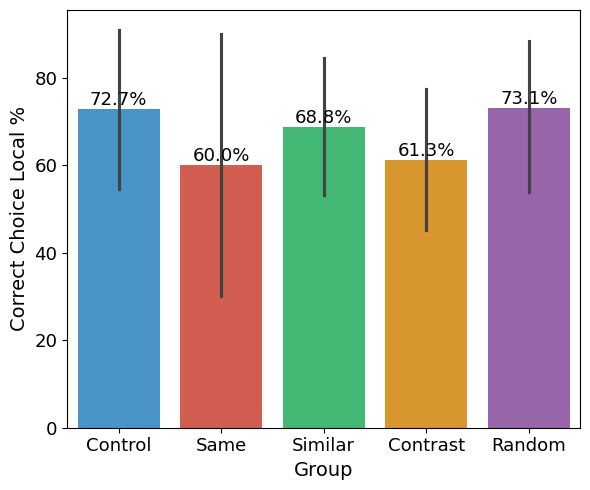

ANOVA F=0.3564, p=0.8391  |  Kruskal-Wallis H=1.4570, p=0.8342
 group_1 group_2     U      p
Contrast Control 302.0 0.3969
Contrast  Random 355.5 0.3565
Contrast    Same 157.0 0.9570
Contrast Similar 459.0 0.5434
 Control  Random 285.0 0.9893
 Control    Same 124.0 0.4944
 Control Similar 366.0 0.7638
  Random    Same 147.0 0.4653
  Random Similar 434.0 0.7286
    Same Similar 146.0 0.6255


In [83]:
# Plot: Correct Choice (Local) by Group
plot_barplot(choices_results, 'group_label', 'good_choice_local',
             y_label='Correct Choice Local %', palette=colors_palette,
             order=group_names, x_val_names=group_names)
anova_test(choices_results, 'good_choice_local', 'group_label')
mannwhitneyu_test(choices_results, 'good_choice_local', 'group_label')

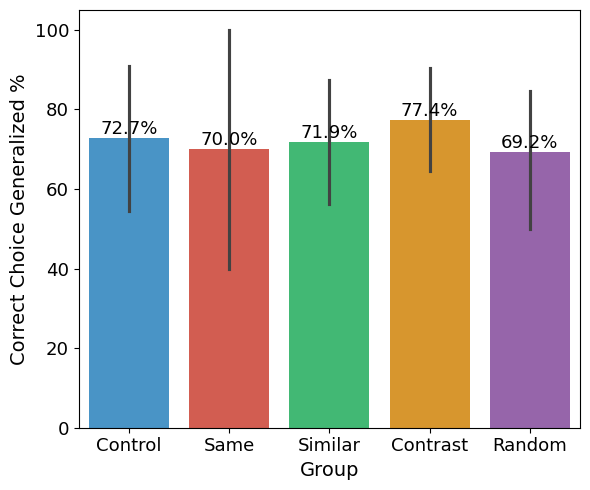

ANOVA F=0.1333, p=0.9699  |  Kruskal-Wallis H=0.5490, p=0.9686
 group_1 group_2     U      p
Contrast Control 357.0 0.7074
Contrast  Random 436.0 0.4949
Contrast    Same 166.5 0.6535
Contrast Similar 523.5 0.6225
 Control  Random 296.0 0.8029
 Control    Same 113.0 0.8962
 Control Similar 355.0 0.9548
  Random    Same 129.0 0.9823
  Random Similar 405.0 0.8351
    Same Similar 157.0 0.9248


In [84]:
# Plot: Correct Choice (Generalized) by Group
plot_barplot(choices_results, 'group_label', 'good_choice_global',
             y_label='Correct Choice Generalized %', palette=colors_palette,
             order=group_names, x_val_names=group_names)
anova_test(choices_results, 'good_choice_global', 'group_label')
mannwhitneyu_test(choices_results, 'good_choice_global', 'group_label')

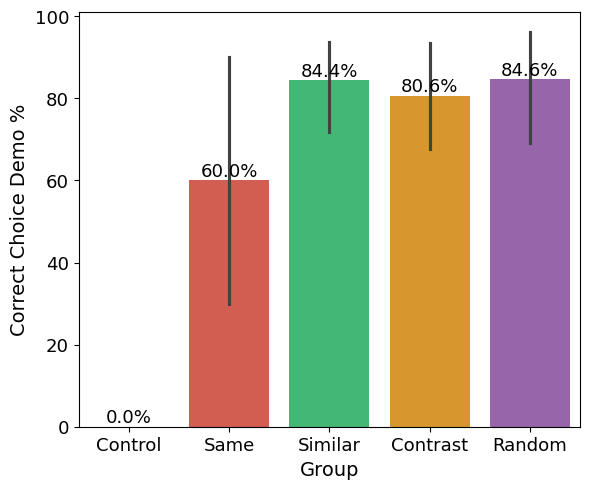

ANOVA F=23.9654, p=0.0000  |  Kruskal-Wallis H=54.2967, p=0.0000
 group_1 group_2     U      p
Contrast Control 616.0 0.0000
Contrast  Random 387.0 0.7062
Contrast    Same 187.0 0.1987
Contrast Similar 477.5 0.7067
 Control  Random  44.0 0.0000
 Control    Same  44.0 0.0001
 Control Similar  55.0 0.0000
  Random    Same 162.0 0.1225
  Random Similar 417.0 0.9901
    Same Similar 121.0 0.1098


In [85]:
# Plot: Correct Choice (demo) by Group
plot_barplot(choices_results, 'group_label', 'good_choice_demo',
             y_label='Correct Choice Demo %', palette=colors_palette,
             order=group_names, x_val_names=group_names)
anova_test(choices_results, 'good_choice_demo', 'group_label')
mannwhitneyu_test(choices_results, 'good_choice_demo', 'group_label')

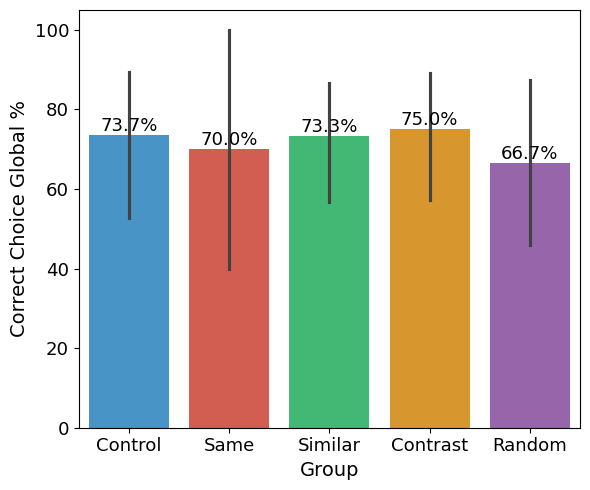

ANOVA F=0.1289, p=0.9716  |  Kruskal-Wallis H=0.5324, p=0.9703
 group_1 group_2     U      p
Contrast Control 269.5 0.9314
Contrast  Random 364.0 0.5201
Contrast    Same 147.0 0.7776
Contrast Similar 427.0 0.8939
 Control  Random 244.0 0.6338
 Control    Same  98.5 0.8590
 Control Similar 286.0 0.9893
  Random    Same 116.0 0.8704
  Random Similar 336.0 0.6051
    Same Similar 145.0 0.8558


In [86]:
# Plot: Correct Choice by Group - only choices with more then 2 feedbacks
min_feedback = 2
y_col = 'good_choice_global'
plot_barplot(choices_results[choices_results['feedback_count'] >= min_feedback], 'group_label', y_col,
             y_label='Correct Choice Global %', palette=colors_palette,
             order=group_names, x_val_names=group_names)
anova_test(choices_results[choices_results['feedback_count'] >= min_feedback], y_col, 'group_label')
mannwhitneyu_test(choices_results[choices_results['feedback_count'] >= min_feedback], y_col, 'group_label')

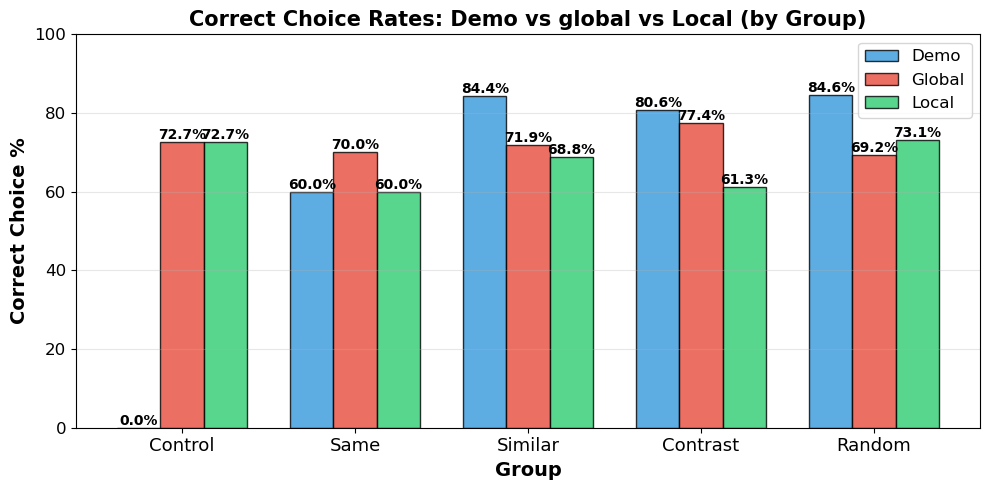


CORRECT CHOICE RATES BY GROUP (%)
   Group  Demo  Global  Local
 Control  0.00   72.73  72.73
    Same 60.00   70.00  60.00
 Similar 84.38   71.88  68.75
Contrast 80.65   77.42  61.29
  Random 84.62   69.23  73.08


In [87]:
# Grouped bar plot: Demo, Global, and Local correct choice percentages by group

choice_metrics_data = []
for group in group_names:
    df_group = choices_results[choices_results['group_label'] == group]
    choice_metrics_data.append({
        'Group': group,
        'Demo': df_group['good_choice_demo'].mean() * 100,
        'Global': df_group['good_choice_global'].mean() * 100,
        'Local': df_group['good_choice_local'].mean() * 100
    })

df_metrics = pd.DataFrame(choice_metrics_data)

# Reshape for grouped bar plot
df_melted = df_metrics.melt(id_vars='Group', var_name='Choice Type', value_name='Percentage')

# Create grouped bar plot
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(group_names))
width = 0.25

demo_vals = df_metrics['Demo'].values
global_vals = df_metrics['Global'].values
local_vals = df_metrics['Local'].values

bars1 = ax.bar(x - width, demo_vals, width, label='Demo', color='#3498db', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x, global_vals, width, label='Global', color='#e74c3c', alpha=0.8, edgecolor='black')
bars3 = ax.bar(x + width, local_vals, width, label='Local', color='#2ecc71', alpha=0.8, edgecolor='black')

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Group', fontsize=14, fontweight='bold')
ax.set_ylabel('Correct Choice %', fontsize=14, fontweight='bold')
ax.set_title('Correct Choice Rates: Demo vs global vs Local (by Group)', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(group_names, fontsize=13)
ax.legend(fontsize=12, loc='upper right')
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

# Print summary table
print("\n" + "="*70)
print("CORRECT CHOICE RATES BY GROUP (%)")
print("="*70)
print(df_metrics.to_string(index=False, float_format='%.2f'))


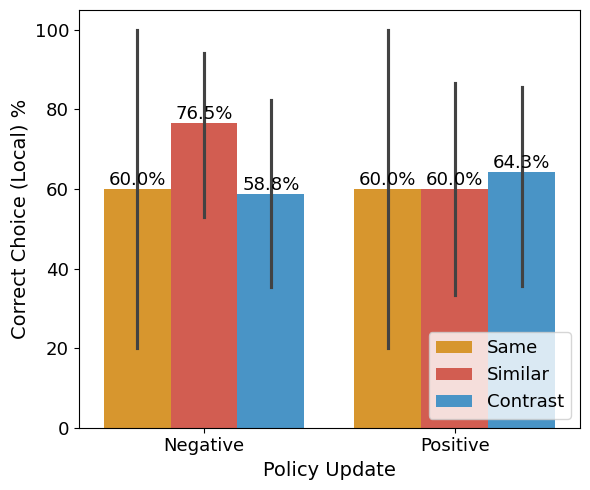

--- Positive updates ---
 group_1 group_2     U      p
Contrast    Same  36.5 0.9119
Contrast Similar 109.5 0.8355
    Same Similar  37.5 1.0000
--- Negative updates ---
 group_1 group_2     U      p
Contrast    Same  42.0 1.0000
Contrast Similar 119.0 0.2881
    Same Similar  35.5 0.5096


In [88]:
# Plot: Correct Choice (Local) by Update Direction — Same vs Contrast
plot_df = choices_results[choices_results['group_label'].isin(['Same', 'Similar', 'Contrast'])].copy()
plot_barplot(plot_df, 'improved_from_prev_feedback', 'good_choice_local',
             y_label='Correct Choice (Local) %', x_label='Policy Update',
             x_val_names=['Negative', 'Positive'], hue='group_label',
             palette=['#f39c12', '#e74c3c', '#3498db', '#2ecc71'])
print("--- Positive updates ---")
mannwhitneyu_test(plot_df[plot_df['improved_from_prev_feedback']==1], 'good_choice_local', 'group_label')
print("--- Negative updates ---")
mannwhitneyu_test(plot_df[plot_df['improved_from_prev_feedback']==0], 'good_choice_local', 'group_label')

In [89]:
choices_results.groupby(['group_label', 'improved_from_prev_feedback'])['good_choice_local'].mean()

group_label  improved_from_prev_feedback
Contrast     0                              0.588235
             1                              0.642857
Control      0                              0.555556
             1                              0.846154
Random       0                              0.666667
             1                              0.764706
Same         0                              0.600000
             1                              0.600000
Similar      0                              0.764706
             1                              0.600000
Name: good_choice_local, dtype: float64

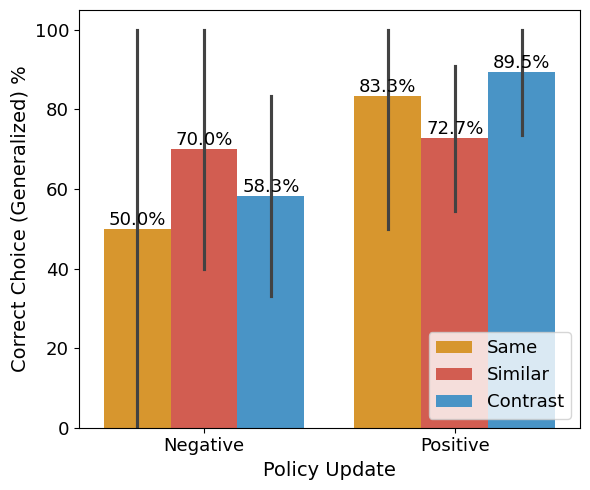

--- Positive updates ---
 group_1 group_2     U      p
Contrast    Same  60.5 0.7347
Contrast Similar 244.0 0.1890
    Same Similar  73.0 0.6277
--- Negative updates ---
 group_1 group_2    U      p
Contrast    Same 26.0 0.8327
Contrast Similar 53.0 0.6073
    Same Similar 16.0 0.5519


In [117]:
# Plot: Correct Choice (Generalized) by Update Direction — Same vs Contrast
plot_df = choices_results[choices_results['group_label'].isin(['Same', 'Similar', 'Contrast'])].copy()
plot_barplot(plot_df, 'improved_from_prev_mean', 'good_choice_global',
             y_label='Correct Choice (Generalized) %', x_label='Policy Update',
             x_val_names=['Negative', 'Positive'], hue='group_label',
             palette=['#f39c12', '#e74c3c', '#3498db', '#2ecc71'])
print("--- Positive updates ---")
mannwhitneyu_test(plot_df[plot_df['improved_from_prev_mean']==1], 'good_choice_global', 'group_label')
print("--- Negative updates ---")
mannwhitneyu_test(plot_df[plot_df['improved_from_prev_mean']==0], 'good_choice_global', 'group_label')

## Agent Rating

In [128]:
user_question_mapping

{'Q205_1': "The explanations of the agent's paths were clear and easy to understand",
 'Q205_3': 'The explanations felt too detailed and overwhelming',
 'Q205_4': "The explanations helped me see how my feedback changed the agent's behavior",
 'Q205_5': 'The visual demonstrations of policy changes helped me understand the differences between agents',
 'Q205_6': "My feedback helped improve the agent's performance",
 'ai:': 'How familiar are you with Artificial Intelligence?',
 'AI_1': 'I believe AI will improve my life',
 'AI_2': 'I believe that AI will improve my work',
 'AI_3': 'I think I will use AI technology in the future',
 'AI_4': 'I think AI technology is a threat to humans',
 'AI_5': 'I think AI technology is positive for humanity'}

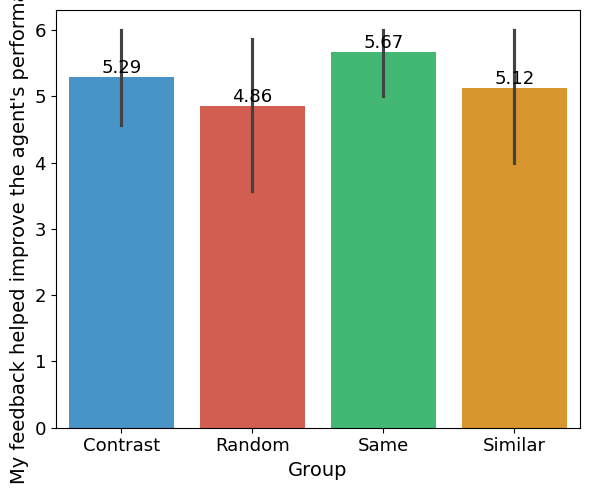

 group_1 group_2    U      p
Contrast  Random 25.0 0.5533
Contrast    Same  8.0 0.3163
Contrast Similar 27.5 0.5000
  Random    Same  7.5 0.2644
  Random Similar 27.0 0.4752
    Same Similar 15.0 0.7790


In [137]:
# user satisfaction with the feedback and explanations
y_column = 'Q205_6'
user_results_p = user_results[user_results[y_column].notnull()].copy()
user_results_p[y_column] = user_results_p[y_column].astype(int)
plot_barplot(user_results_p, 'group_label', y_column,
             y_label=user_question_mapping[y_column], palette=colors_palette,
             estimator=lambda x: np.mean(x), bar_label_fmt='%.2f')
mannwhitneyu_test(user_results_p, y_column, 'group_label', test_type='less')

### Choice Time

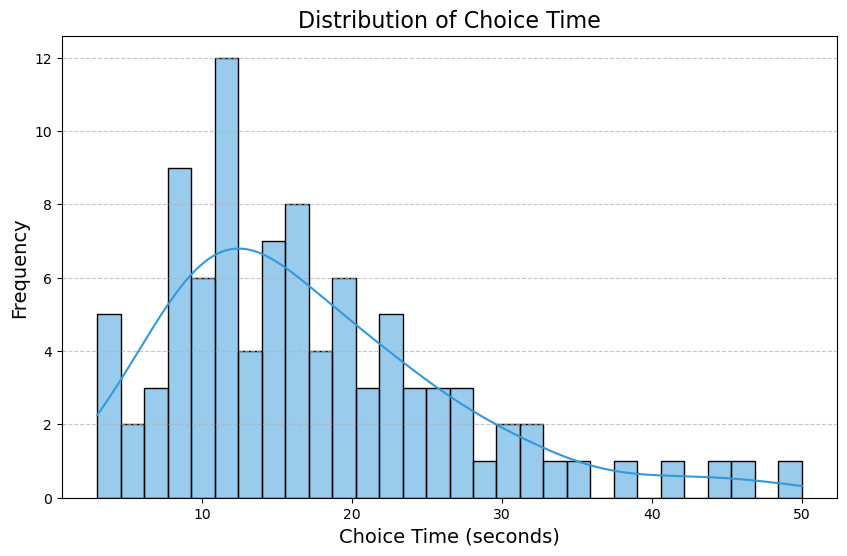

count    95.000000
mean     17.315789
std       9.761260
min       3.000000
25%      10.000000
50%      15.000000
75%      22.000000
max      50.000000
Name: choice_time, dtype: float64

In [122]:
plt.figure(figsize=(10, 6))
plot_df = choices_results[(choices_results['choice_time'] < 60) & (choices_results['choice_time'] > 0)]  # Filter out extreme outliers for better visualization

sns.histplot(plot_df['choice_time'], kde=True, color='#3498db', bins=30)
plt.title('Distribution of Choice Time', fontsize=16)
plt.xlabel('Choice Time (seconds)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

plot_df['choice_time'].describe()

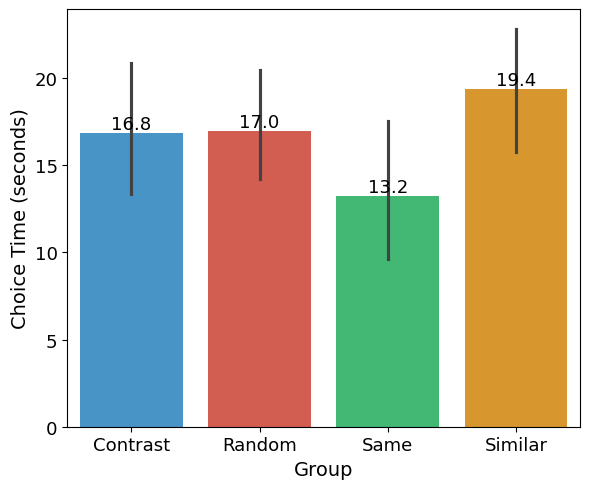

ANOVA F=1.0964, p=0.3548  |  Kruskal-Wallis H=3.4858, p=0.3226
 group_1 group_2     U      p
Contrast  Random 348.0 0.8410
Contrast    Same 177.0 0.4069
Contrast Similar 393.0 0.3017
  Random    Same 160.0 0.1344
  Random Similar 334.0 0.5240
    Same Similar  95.5 0.0726


In [123]:
plot_df = choices_results[(choices_results['choice_time'] < 60) & (choices_results['choice_time'] > 0)]  # Filter out extreme outliers for better visualization
if plot_df.empty:
    print("No valid choice_time data to plot.")
else:
    plot_barplot(plot_df, 'group_label', 'choice_time', y_label='Choice Time (seconds)', palette=colors_palette,
             bar_label_fmt='%.1f', estimator='mean')
    anova_test(plot_df, 'choice_time', 'group_label')
    mannwhitneyu_test(plot_df, 'choice_time', 'group_label')

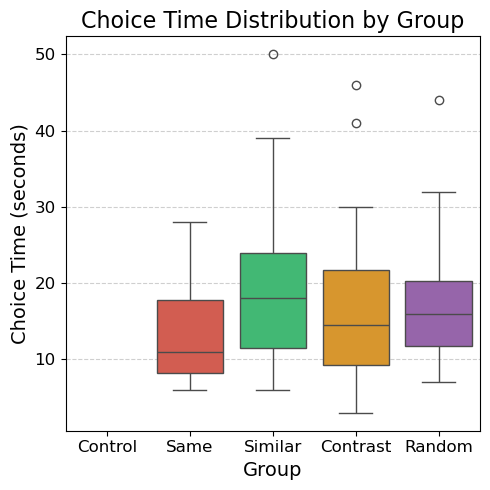

In [124]:
plt.figure(figsize=(5, 5))
sns.boxplot(data=plot_df, x='group_label', y='choice_time', order=group_names, palette=colors_palette)

plt.title('Choice Time Distribution by Group', fontsize=16)
plt.xlabel('Group', fontsize=14)
plt.ylabel('Choice Time (seconds)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Delegation - Trust the Agent

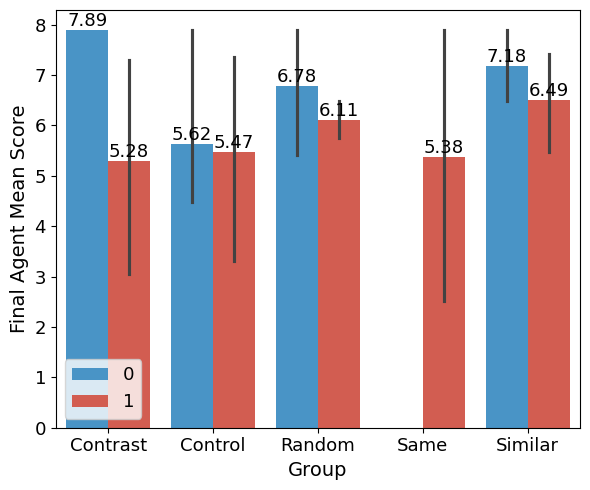


Mann-Whitney U Test for group:
Similar
 group_1  group_2   U      p
       0        1 8.0 0.5991
Contrast
 group_1  group_2   U      p
       0        1 5.0 0.4364
Same
Empty DataFrame
Columns: []
Index: []
Random
 group_1  group_2   U      p
       0        1 6.5 0.6849


In [91]:
# Final agent score by group and trust the agent
plot_barplot(user_results, 'group_label', 'final_agent_mean_score', hue='trust_the_agent',
             y_label='Final Agent Mean Score', x_label='Group',
             estimator = 'mean', bar_label_fmt='%.2f',
            palette=colors_palette)

print("\nMann-Whitney U Test for group:")
print("Similar")
mannwhitneyu_test(user_results[user_results['group_label'] == 'Similar'], 'final_agent_mean_score', 'trust_the_agent')
print("Contrast")
mannwhitneyu_test(user_results[user_results['group_label'] == 'Contrast'], 'final_agent_mean_score', 'trust_the_agent')
print("Same")
mannwhitneyu_test(user_results[user_results['group_label'] == 'Same'], 'final_agent_mean_score', 'trust_the_agent') 
print("Random")
mannwhitneyu_test(user_results[user_results['group_label'] == 'Random'], 'final_agent_mean_score', 'trust_the_agent')

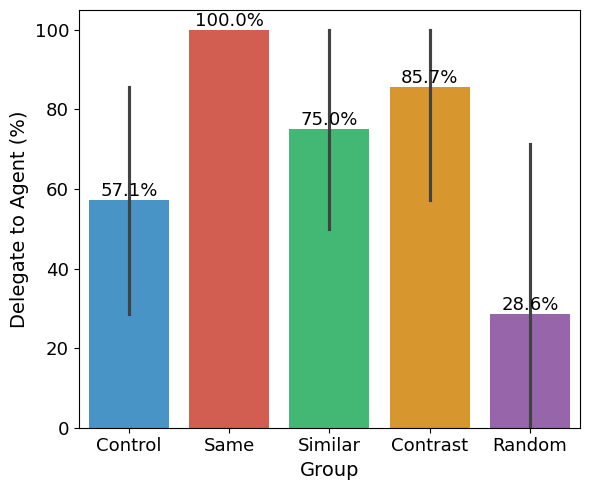

ANOVA F=2.1094, p=0.1072  |  Kruskal-Wallis H=7.3810, p=0.1171
 group_1 group_2    U      p
Contrast Control 31.5 0.8891
Contrast  Random 38.5 0.9845
Contrast    Same  9.0 0.3313
Contrast Similar 31.0 0.7202
 Control  Random 31.5 0.8676
 Control    Same  6.0 0.1265
 Control Similar 23.0 0.2623
  Random    Same  3.0 0.0334
  Random Similar 15.0 0.0474
    Same Similar 15.0 0.8566


In [92]:
# Plot: Delegate to Agent by Group
plot_barplot(user_results, 'group_label', 'trust_the_agent',
             y_label='Delegate to Agent (%)', palette=colors_palette,
             order=group_names, x_val_names=group_names)
anova_test(user_results, 'trust_the_agent', 'group_label')

mannwhitneyu_test(user_results, 'trust_the_agent', 'group_label', test_type='less')

In [93]:
user_results.columns

Index(['user_id', 'group', 'group_label', 'trust_the_agent', 'tutorial_score',
       'age', 'gender', 'education', 'ai', 'AI_1', 'AI_2', 'AI_3', 'AI_4',
       'AI_5', 'Q205_1', 'Q205_3', 'Q205_4', 'Q205_5', 'Q205_6', 'final_agent',
       'number_of_choices', 'mean_feedback_count', 'mean_good_choice_local',
       'mean_good_choice_global', 'mean_agent_rating', 'final_score',
       'final_agent_mean_score', 'user_satisfaction'],
      dtype='object')

In [95]:
user_results.columns

Index(['user_id', 'group', 'group_label', 'trust_the_agent', 'tutorial_score',
       'age', 'gender', 'education', 'ai', 'AI_1', 'AI_2', 'AI_3', 'AI_4',
       'AI_5', 'Q205_1', 'Q205_3', 'Q205_4', 'Q205_5', 'Q205_6', 'final_agent',
       'number_of_choices', 'mean_feedback_count', 'mean_good_choice_local',
       'mean_good_choice_global', 'mean_agent_rating', 'final_score',
       'final_agent_mean_score', 'user_satisfaction'],
      dtype='object')

In [96]:
user_results['trust_the_agent'].value_counts()

trust_the_agent
1    21
0    11
Name: count, dtype: int64

## Final Agent

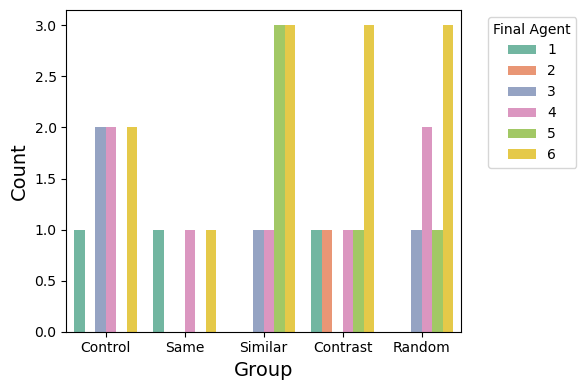

In [97]:
# Plot: Count of Final Agent by Group
grouped = user_results.groupby(['group_label', 'final_agent']).size().reset_index(name='count')
plt.figure(figsize=(6, 4))
sns.barplot(data=grouped, x='group_label', y='count', hue='final_agent',
            order=group_names, palette='Set2')
plt.legend(title='Final Agent', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel('Group', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.tight_layout()
plt.show()

## Config Change


In [ ]:
plot_df = choices_results[choices_results['demonstration_config'] >= 0].copy()
plot_df['config_change'] = plot_df.apply(lambda r: f"{r['feedback_config']}-{r['demonstration_config']}", axis=1)

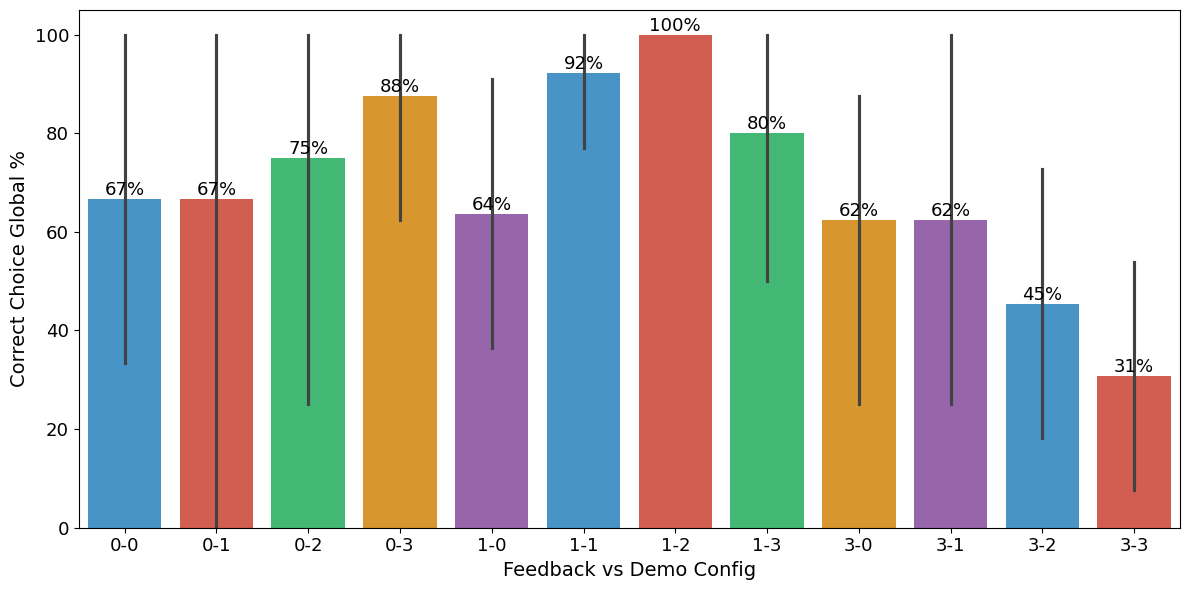

config_change
1-1    13
3-3    13
1-0    11
3-2    11
1-3    10
3-0     8
0-3     8
3-1     8
0-0     6
1-2     4
0-2     4
0-1     3
Name: count, dtype: int64

In [143]:

plot_barplot(plot_df, 'config_change', 'good_choice_local', y_label='Correct Choice Global %',# hue='group_label',
             x_label='Feedback vs Demo Config', palette=colors_palette, figsize=(12,6), bar_label_fmt='%.f%%')

plot_df['config_change'].value_counts()

# More plots

In [98]:
choices_results.columns

Index(['user_id', 'episode_index', 'group', 'prev_agent', 'updated_agent',
       'choice', 'good_choice_local', 'good_choice_global', 'good_choice_demo',
       'final_agent', 'feedback_config', 'feedback_level',
       'demonstration_config', 'demonstration_level', 'demo_prev_score',
       'demo_updated_score', 'feedback_count', 'feedback_correctness',
       'agent_rating', 'trust_the_agent', 'choice_time', 'group_label',
       'improved_from_prev_feedback', 'improved_from_prev_mean'],
      dtype='object')

group_label  demonstration_config
Contrast      0                       5
              1                       9
              2                       6
              3                      11
Control      -1                      22
Random        0                       9
              1                       6
              2                       6
              3                       5
Same          0                       2
              1                       2
              2                       2
              3                       4
Similar       0                       9
              1                       7
              2                       5
              3                      11
Name: good_choice_global, dtype: int64


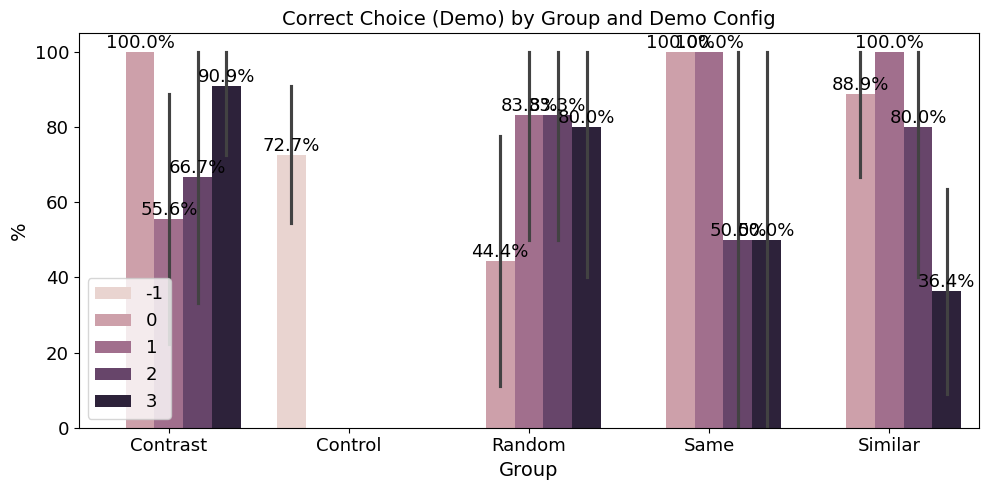

In [99]:
plot_df = choices_results.dropna(subset=['good_choice_demo', 'demonstration_config'])
print(plot_df.groupby(['group_label', 'demonstration_config'])['good_choice_global'].count())
plot_barplot(plot_df, 'group_label', 'good_choice_global', hue='demonstration_config',  
             figsize=(10,5),title='Correct Choice (Demo) by Group and Demo Config')

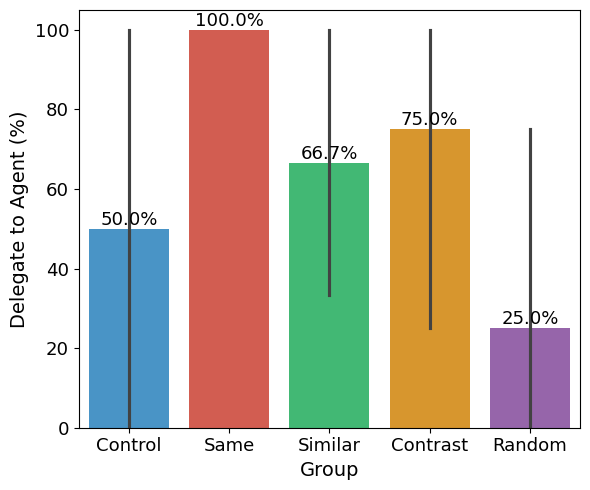

ANOVA F=2.1094, p=0.1072  |  Kruskal-Wallis H=7.3810, p=0.1171
 group_1 group_2    U      p
Contrast Control 31.5 0.8891
Contrast  Random 38.5 0.9845
Contrast    Same  9.0 0.3313
Contrast Similar 31.0 0.7202
 Control  Random 31.5 0.8676
 Control    Same  6.0 0.1265
 Control Similar 23.0 0.2623
  Random    Same  3.0 0.0334
  Random Similar 15.0 0.0474
    Same Similar 15.0 0.8566


In [100]:
# Plot: Delegate to Agent by Group (only users that ended with agent 6)
plot_barplot(user_results[(user_results['final_agent'] == 6) | (user_results['final_agent'] == 5)], 'group_label', 'trust_the_agent',
             y_label='Delegate to Agent (%)', palette=colors_palette,
             order=group_names, x_val_names=group_names)
anova_test(user_results, 'trust_the_agent', 'group_label')
mannwhitneyu_test(user_results, 'trust_the_agent', 'group_label', test_type='less')

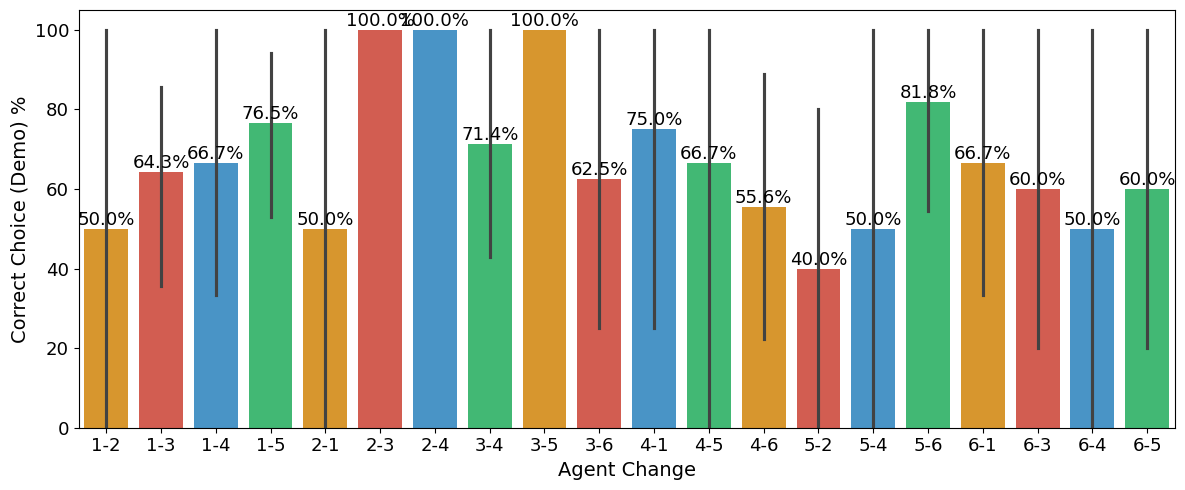

agent_change
1-5    17
1-3    14
5-6    11
1-4     9
4-6     9
3-6     8
3-4     7
6-1     6
6-3     5
5-2     5
6-5     5
1-2     4
6-4     4
5-4     4
4-1     4
4-5     3
3-5     2
2-1     2
2-4     1
2-3     1
Name: count, dtype: int64

In [101]:
plot_df = choices_results.copy()
plot_df["agent_change"] = plot_df.apply(lambda r: f"{r['prev_agent']}-{r['updated_agent']}", axis=1)
plot_barplot(plot_df, 'agent_change', 'good_choice_demo',
             y_label='Correct Choice (Demo) %', x_label='Agent Change',
             figsize=(12, 5),
            #  x_val_names=plot_df['agent_change'].unique(),
             palette=['#f39c12', '#e74c3c', '#3498db', '#2ecc71'])
plot_df['agent_change'].value_counts()

In [102]:
choices_results.columns

Index(['user_id', 'episode_index', 'group', 'prev_agent', 'updated_agent',
       'choice', 'good_choice_local', 'good_choice_global', 'good_choice_demo',
       'final_agent', 'feedback_config', 'feedback_level',
       'demonstration_config', 'demonstration_level', 'demo_prev_score',
       'demo_updated_score', 'feedback_count', 'feedback_correctness',
       'agent_rating', 'trust_the_agent', 'choice_time', 'group_label',
       'improved_from_prev_feedback', 'improved_from_prev_mean'],
      dtype='object')

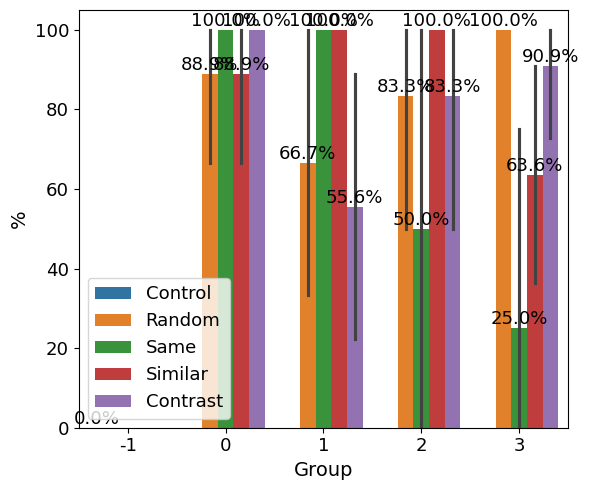

In [103]:
plot_barplot(choices_results, 'demonstration_config', 'good_choice_demo', hue='group_label',)

In [104]:
plot_df['agent_change'].value_counts()

agent_change
1-5    17
1-3    14
5-6    11
1-4     9
4-6     9
3-6     8
3-4     7
6-1     6
6-3     5
5-2     5
6-5     5
1-2     4
6-4     4
5-4     4
4-1     4
4-5     3
3-5     2
2-1     2
2-4     1
2-3     1
Name: count, dtype: int64

In [105]:
import pandas as pd
models_scores = pd.read_csv('../results/simple_eval2.csv')

def get_level_score(models_scores, model_index, config_index, level):
    return models_scores[(models_scores['model_index'] == model_index) & (models_scores['config_index'] == config_index) & (models_scores['start_level'] == level)]['total_reward'].values[0]

def get_config_mean_score(models_scores, model_index, config_index):
    return np.mean(models_scores[(models_scores['model_index'] == model_index) & (models_scores['config_index'] == config_index)]['total_reward'].values)

models_scores.head()

,total_reward,episode_length,good_food_collected,bad_food_touched,wall_hits,completed,model_index,model_name,config_index,config_name,start_level
0,11.0,132,4,3,0,True,1,no_doors_collect_all,0,no_walls,0
1,11.0,132,4,3,0,True,1,no_doors_collect_all,0,no_walls,1
2,10.0,132,2,4,0,True,1,no_doors_collect_all,0,no_walls,2
3,11.0,132,4,3,0,True,1,no_doors_collect_all,0,no_walls,3
4,10.0,132,3,3,0,True,1,no_doors_collect_all,0,no_walls,4


In [106]:
choices_results.columns

Index(['user_id', 'episode_index', 'group', 'prev_agent', 'updated_agent',
       'choice', 'good_choice_local', 'good_choice_global', 'good_choice_demo',
       'final_agent', 'feedback_config', 'feedback_level',
       'demonstration_config', 'demonstration_level', 'demo_prev_score',
       'demo_updated_score', 'feedback_count', 'feedback_correctness',
       'agent_rating', 'trust_the_agent', 'choice_time', 'group_label',
       'improved_from_prev_feedback', 'improved_from_prev_mean'],
      dtype='object')

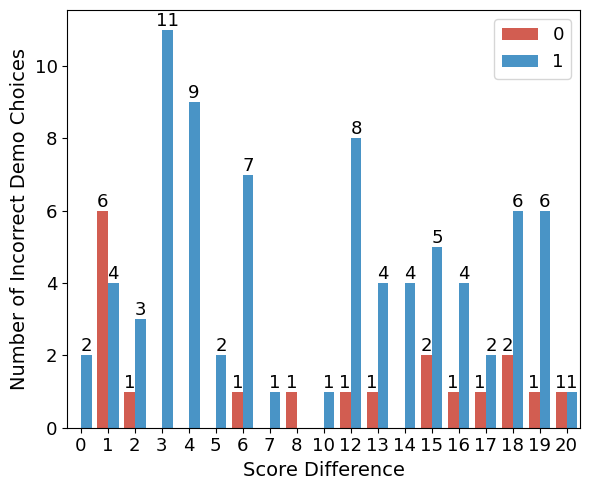

In [107]:

plot_df = choices_results[choices_results['good_choice_demo'] == 0].copy()
plot_df = choices_results[choices_results['demo_prev_score'].notnull()].copy()
plot_df["agent_change"] = plot_df.apply(lambda r: f"{r['prev_agent']}-{r['updated_agent']}", axis=1)
plot_df['demo_score_diff'] = plot_df.apply(lambda r: int(np.abs(r['demo_prev_score'] - r['demo_updated_score'])), axis=1)
plot_barplot(plot_df, 'demo_score_diff', 'choice',
             y_label='Number of Incorrect Demo Choices', x_label='Score Difference',
             estimator=len, hue='good_choice_demo',
             bar_label_fmt='%.0f',
            #  x_val_names=plot_df['agent_change'].unique(),
             palette=['#e74c3c', '#3498db', '#2ecc71'])

In [108]:
plot_df[plot_df['demo_score_diff'] == 1][['agent_change', 'demonstration_config', 'demonstration_level']].value_counts()

agent_change  demonstration_config  demonstration_level
1-3           1                     6                      1
1-5           2                     95                     1
              3                     34                     1
                                    48                     1
4-1           0                     5                      1
              3                     47                     1
5-6           0                     90                     1
              3                     7                      1
6-4           2                     29                     1
6-5           1                     81                     1
Name: count, dtype: int64

In [109]:
plot_df[plot_df['agent_change'] == '1-5'][['group', 'choice', 'good_choice_global', 'good_choice_local', 'feedback_config', 'demonstration_config', 'demonstration_level']].head(10)

,group,choice,good_choice_global,good_choice_local,feedback_config,demonstration_config,demonstration_level
5,4,1,1,1,1,3,40
11,4,1,1,1,0,0,64
13,4,1,1,1,1,1,9
19,1,0,0,0,3,3,48
20,1,1,1,1,0,3,34
26,2,0,0,0,0,3,74
27,2,1,1,1,1,0,51
47,4,1,1,1,3,1,35
52,2,1,1,1,0,3,74
62,3,1,1,1,0,3,53


In [110]:
plot_df[['good_choice_demo', 'good_choice_global', 'good_choice_local']].value_counts()

good_choice_demo  good_choice_global  good_choice_local
1                 1                   1                    55
0                 0                   0                    12
1                 1                   0                    12
                  0                   0                     9
0                 1                   1                     5
1                 0                   1                     4
0                 0                   1                     2
Name: count, dtype: int64

In [111]:
# Analysis of bad demonstration choices by different conditions

def analyze_bad_choices(df, condition_col, condition_name):
    """Calculate bad choice rate for each level of a condition"""
    summary = df.groupby(condition_col).agg({
        'good_choice_demo': ['count', 'sum']
    }).reset_index()
    summary.columns = [condition_col, 'total_choices', 'good_choices']
    summary['bad_choices'] = summary['total_choices'] - summary['good_choices']
    summary['bad_choice_rate'] = (summary['bad_choices'] / summary['total_choices'] * 100).round(2)
    summary['good_choice_rate'] = (summary['good_choices'] / summary['total_choices'] * 100).round(2)
    
    print(f"\n{'='*70}")
    print(f"{condition_name}")
    print(f"{'='*70}")
    print(summary.to_string(index=False))
    return summary

# Analyze by different conditions
summary_group = analyze_bad_choices(choices_results, 'group_label', 'BAD CHOICE RATE BY GROUP')
summary_config = analyze_bad_choices(choices_results, 'demonstration_config', 'BAD CHOICE RATE BY DEMONSTRATION CONFIG')
summary_episode = analyze_bad_choices(choices_results, 'episode_index', 'BAD CHOICE RATE BY EPISODE INDEX')
summary_choice = analyze_bad_choices(choices_results, 'choice', 'BAD CHOICE RATE BY USER CHOICE (0=Stay, 1=Update)')

# Overall statistics
total = len(choices_results)
bad_total = (choices_results['good_choice_demo'] == 0).sum()
print(f"\n{'='*70}")
print(f"OVERALL STATISTICS")
print(f"{'='*70}")
print(f"Total choices: {total}")
print(f"Bad choices (demo): {bad_total} ({bad_total/total*100:.2f}%)")
print(f"Good choices (demo): {total - bad_total} ({(total - bad_total)/total*100:.2f}%)")



BAD CHOICE RATE BY GROUP
group_label  total_choices  good_choices  bad_choices  bad_choice_rate  good_choice_rate
   Contrast             31            25            6            19.35             80.65
    Control             22             0           22           100.00              0.00
     Random             26            22            4            15.38             84.62
       Same             10             6            4            40.00             60.00
    Similar             32            27            5            15.62             84.38

BAD CHOICE RATE BY DEMONSTRATION CONFIG
 demonstration_config  total_choices  good_choices  bad_choices  bad_choice_rate  good_choice_rate
                   -1             22             0           22           100.00              0.00
                    0             25            23            2             8.00             92.00
                    1             24            18            6            25.00             75.00
   

Correlation: good_choice_demo vs good_choice_global (by group)
   Group  Pearson_r  Pearson_p  Spearman_r  Spearman_p   N
 Control        NaN        NaN         NaN         NaN  22
    Same     0.8018     0.0053      0.8018      0.0053  10
 Similar     0.6879     0.0000      0.6879      0.0000  32
Contrast     0.5166     0.0029      0.5166      0.0029  31
  Random     0.1777     0.3852      0.1777      0.3852  26
 Overall     0.3457     0.0001      0.3457      0.0001 121


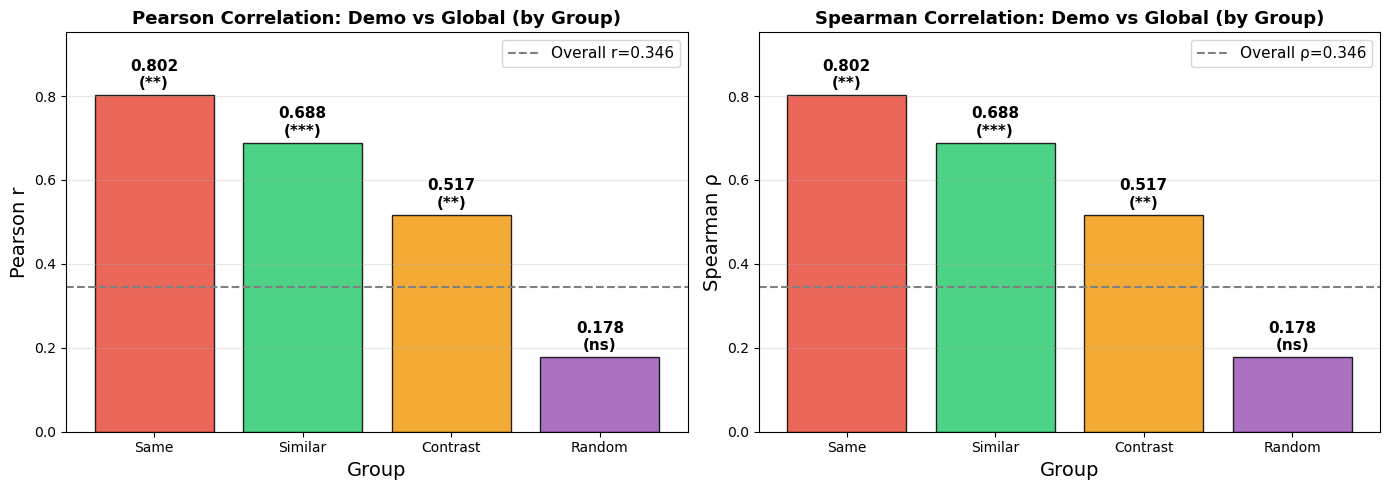

In [112]:

# Calculate correlations between good_choice_demo and good_choice_global by group
from scipy.stats import pearsonr, spearmanr

print("="*70)
print("Correlation: good_choice_demo vs good_choice_global (by group)")
print("="*70)

corr_rows = []
for group in group_names:
    df_g = choices_results[choices_results['group_label'] == group]
    demo = df_g['good_choice_demo']
    glob = df_g['good_choice_global']
    pr, pp = pearsonr(demo, glob)
    sr, sp = spearmanr(demo, glob)
    corr_rows.append({'Group': group, 'Pearson_r': round(pr, 4), 'Pearson_p': round(pp, 4),
                      'Spearman_r': round(sr, 4), 'Spearman_p': round(sp, 4), 'N': len(df_g)})

# Overall
demo_all = choices_results['good_choice_demo']
glob_all = choices_results['good_choice_global']
pr, pp = pearsonr(demo_all, glob_all)
sr, sp = spearmanr(demo_all, glob_all)
corr_rows.append({'Group': 'Overall', 'Pearson_r': round(pr, 4), 'Pearson_p': round(pp, 4),
                  'Spearman_r': round(sr, 4), 'Spearman_p': round(sp, 4), 'N': len(choices_results)})

corr_df = pd.DataFrame(corr_rows)
print(corr_df.to_string(index=False))

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot of Pearson correlations by group
groups_only = corr_df[corr_df['Group'] != 'Overall']
bars = axes[0].bar(groups_only['Group'], groups_only['Pearson_r'],
                   color=colors_palette[:len(groups_only)], edgecolor='black', alpha=0.85)
for bar, p_val in zip(bars, groups_only['Pearson_p']):
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}\n({sig})', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Pearson r', fontsize=14)
axes[0].set_xlabel('Group', fontsize=14)
axes[0].set_title('Pearson Correlation: Demo vs Global (by Group)', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, min(1.0, groups_only['Pearson_r'].max() + 0.15))
axes[0].axhline(y=corr_df[corr_df['Group']=='Overall']['Pearson_r'].values[0],
                color='gray', linestyle='--', linewidth=1.5, label=f"Overall r={pr:.3f}")
axes[0].legend(fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# Bar plot of Spearman correlations by group
bars2 = axes[1].bar(groups_only['Group'], groups_only['Spearman_r'],
                    color=colors_palette[:len(groups_only)], edgecolor='black', alpha=0.85)
for bar, p_val in zip(bars2, groups_only['Spearman_p']):
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}\n({sig})', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Spearman ρ', fontsize=14)
axes[1].set_xlabel('Group', fontsize=14)
axes[1].set_title('Spearman Correlation: Demo vs Global (by Group)', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, min(1.0, groups_only['Spearman_r'].max() + 0.15))
axes[1].axhline(y=corr_df[corr_df['Group']=='Overall']['Spearman_r'].values[0],
                color='gray', linestyle='--', linewidth=1.5, label=f"Overall ρ={sr:.3f}")
axes[1].legend(fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


CROSSTAB & AGREEMENT: good_choice_demo vs good_choice_global

--- Control (N=22) ---
  Demo correct rate:   0.0%
  Global correct rate: 72.7%
  Agreement rate:      27.3%
  Max possible phi:    1.000
good_choice_global  0   1  All
good_choice_demo              
0                   6  16   22
All                 6  16   22

--- Same (N=10) ---
  Demo correct rate:   60.0%
  Global correct rate: 70.0%
  Agreement rate:      90.0%
  Max possible phi:    0.535
good_choice_global  0  1  All
good_choice_demo             
0                   3  1    4
1                   0  6    6
All                 3  7   10

--- Similar (N=32) ---
  Demo correct rate:   84.4%
  Global correct rate: 71.9%
  Agreement rate:      87.5%
  Max possible phi:    0.269
good_choice_global  0   1  All
good_choice_demo              
0                   5   0    5
1                   4  23   27
All                 9  23   32

--- Contrast (N=31) ---
  Demo correct rate:   80.6%
  Global correct rate: 77.4%
  Agreement

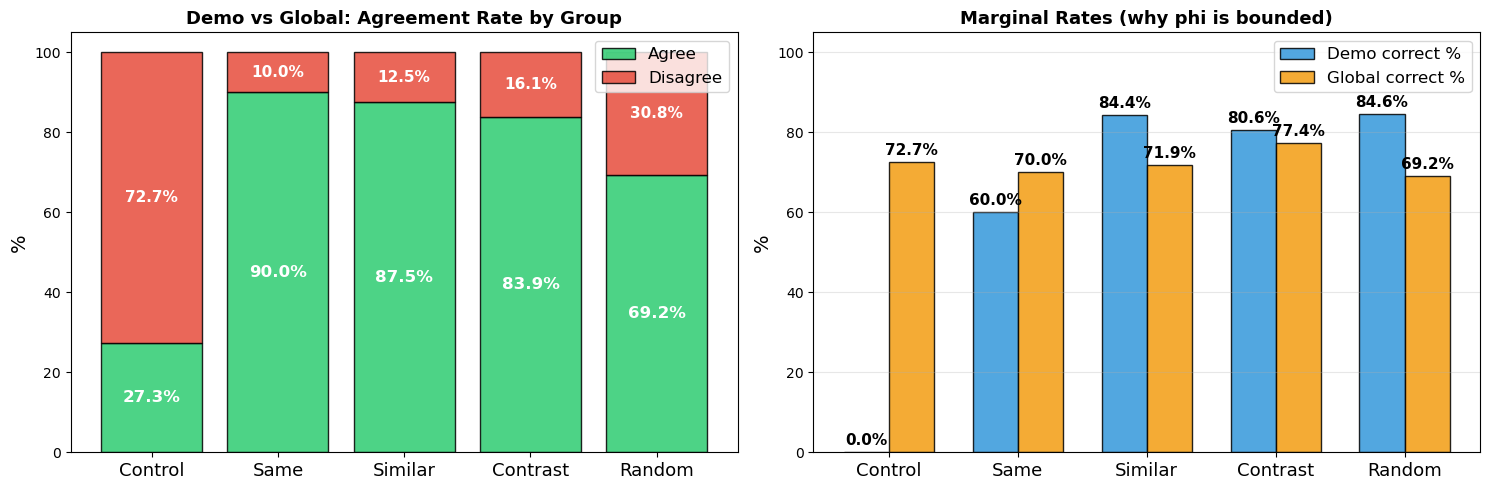


KEY INSIGHT: For binary×binary data, Pearson r = phi coefficient.
Phi is bounded by marginal distributions — when one variable has a
much higher base rate than the other, the max possible phi << 1.0.
Agreement % is a better measure of how often demo & global match.


In [113]:

# Diagnostic: Why are correlations low? → Both variables are binary (0/1)
# For binary data, Pearson r = phi coefficient, which is bounded by marginal distributions.
# Crosstabs + % agreement are more informative.

from scipy.stats import chi2_contingency

print("="*70)
print("CROSSTAB & AGREEMENT: good_choice_demo vs good_choice_global")
print("="*70)

agreement_rows = []
for group in group_names + ['Overall']:
    df_g = choices_results if group == 'Overall' else choices_results[choices_results['group_label'] == group]
    ct = pd.crosstab(df_g['good_choice_demo'], df_g['good_choice_global'], margins=True)
    
    # Agreement = both 0 or both 1
    both_0 = ct.loc[0, 0] if 0 in ct.index and 0 in ct.columns else 0
    both_1 = ct.loc[1, 1] if 1 in ct.index and 1 in ct.columns else 0
    n = len(df_g)
    agree_pct = (both_0 + both_1) / n * 100
    
    # Marginal rates (how skewed each variable is)
    demo_rate = df_g['good_choice_demo'].mean() * 100
    global_rate = df_g['good_choice_global'].mean() * 100
    
    # Max possible phi given these marginals
    p1, p2 = df_g['good_choice_demo'].mean(), df_g['good_choice_global'].mean()
    max_phi = np.sqrt((p1 * p2) / ((1-p1) * (1-p2))) if p1 < 1 and p2 < 1 and p1 > 0 and p2 > 0 else 1.0
    max_phi = min(max_phi, 1/max_phi) if max_phi != 0 else 0  # take the smaller bound
    
    agreement_rows.append({
        'Group': group, 'N': n,
        'Demo=1%': f'{demo_rate:.1f}%', 'Global=1%': f'{global_rate:.1f}%',
        'Agree%': f'{agree_pct:.1f}%', 'Max_Phi': f'{max_phi:.3f}',
        'Both_0': both_0, 'Both_1': both_1, 
        'Demo=1_Global=0': ct.loc[1, 0] if 1 in ct.index and 0 in ct.columns else 0,
        'Demo=0_Global=1': ct.loc[0, 1] if 0 in ct.index and 1 in ct.columns else 0
    })
    
    print(f"\n--- {group} (N={n}) ---")
    print(f"  Demo correct rate:   {demo_rate:.1f}%")
    print(f"  Global correct rate: {global_rate:.1f}%")
    print(f"  Agreement rate:      {agree_pct:.1f}%")
    print(f"  Max possible phi:    {max_phi:.3f}")
    print(ct)

agree_df = pd.DataFrame(agreement_rows)

# --- Plot: Agreement breakdown as stacked bars ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: Agreement % vs Disagreement % by group
groups_agree = agree_df[agree_df['Group'] != 'Overall']
x = np.arange(len(groups_agree))
agree_vals = [(r['Both_0'] + r['Both_1']) / r['N'] * 100 for _, r in groups_agree.iterrows()]
disagree_vals = [100 - a for a in agree_vals]

bars1 = axes[0].bar(x, agree_vals, color='#2ecc71', edgecolor='black', alpha=0.85, label='Agree')
bars2 = axes[0].bar(x, disagree_vals, bottom=agree_vals, color='#e74c3c', edgecolor='black', alpha=0.85, label='Disagree')
for i, (a, d) in enumerate(zip(agree_vals, disagree_vals)):
    axes[0].text(i, a/2, f'{a:.1f}%', ha='center', va='center', fontsize=12, fontweight='bold', color='white')
    if d > 5:
        axes[0].text(i, a + d/2, f'{d:.1f}%', ha='center', va='center', fontsize=11, fontweight='bold', color='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(groups_agree['Group'], fontsize=13)
axes[0].set_ylabel('%', fontsize=14)
axes[0].set_title('Demo vs Global: Agreement Rate by Group', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=12)
axes[0].set_ylim(0, 105)

# Right: Marginal rates (how skewed each binary variable is)
width = 0.35
demo_rates = [float(r['Demo=1%'].strip('%')) for _, r in groups_agree.iterrows()]
global_rates = [float(r['Global=1%'].strip('%')) for _, r in groups_agree.iterrows()]
axes[1].bar(x - width/2, demo_rates, width, color='#3498db', edgecolor='black', alpha=0.85, label='Demo correct %')
axes[1].bar(x + width/2, global_rates, width, color='#f39c12', edgecolor='black', alpha=0.85, label='Global correct %')
for i, (d, g) in enumerate(zip(demo_rates, global_rates)):
    axes[1].text(i - width/2, d + 1, f'{d:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
    axes[1].text(i + width/2, g + 1, f'{g:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(groups_agree['Group'], fontsize=13)
axes[1].set_ylabel('%', fontsize=14)
axes[1].set_title('Marginal Rates (why phi is bounded)', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=12)
axes[1].set_ylim(0, 105)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("KEY INSIGHT: For binary×binary data, Pearson r = phi coefficient.")
print("Phi is bounded by marginal distributions — when one variable has a")
print("much higher base rate than the other, the max possible phi << 1.0.")
print("Agreement % is a better measure of how often demo & global match.")
print("="*70)


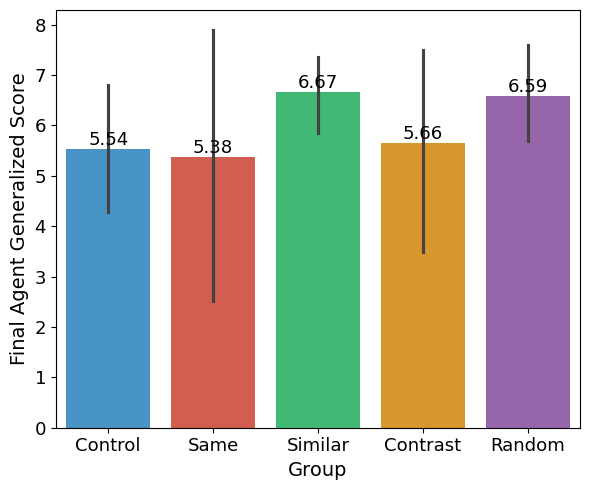

ANOVA F=0.6070, p=0.6610  |  Kruskal-Wallis H=2.0327, p=0.7298
 group_1 group_2    U      p
Contrast Control 27.5 0.3711
Contrast  Random 22.0 0.6559
Contrast    Same 11.5 0.4529
Contrast Similar 24.5 0.6855
 Control  Random 16.0 0.8841
 Control    Same 10.5 0.5468
 Control Similar 17.0 0.9148
  Random    Same 13.5 0.2757
  Random Similar 26.5 0.5958
    Same Similar  8.0 0.8293


In [114]:
# Plot: Final Agent Generalized Score by Group
plot_barplot(user_results, 'group_label', 'final_agent_mean_score',
             y_label='Final Agent Generalized Score', estimator='mean',
             bar_label_fmt='%.2f', palette=colors_palette,
             order=group_names, x_val_names=group_names)
anova_test(user_results, 'final_agent_mean_score', 'group_label')
mannwhitneyu_test(user_results, 'final_agent_mean_score', 'group_label', test_type='greater')

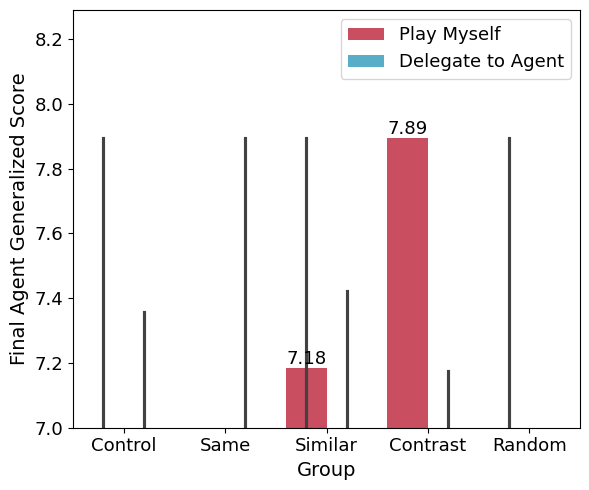


--- Control ---
 group_1  group_2   U   p
       0        1 5.5 0.5

--- Similar ---
 group_1  group_2   U      p
       0        1 8.0 0.8095

--- Contrast ---
 group_1  group_2   U      p
       0        1 5.0 0.9027

--- Random ---
 group_1  group_2   U      p
       0        1 6.5 0.7915


In [115]:
# Plot: Final Agent Generalized Score by Group and Delegate
plot_barplot(user_results, 'group_label', 'final_agent_mean_score',
             y_label='Final Agent Generalized Score', hue='trust_the_agent',
             hue_names=['Play Myself', 'Delegate to Agent'],
             order=group_names, x_val_names=group_names,
             bar_label_fmt='%.2f', estimator='mean',
             palette=["#DC3A52", "#45B6DB"], ylim_bottom=7)

for grp in group_names:
    df_g = user_results[user_results['group_label'] == grp]
    if df_g['trust_the_agent'].nunique() > 1:
        print(f"\n--- {grp} ---")
        mannwhitneyu_test(df_g, 'final_agent_mean_score', 'trust_the_agent', test_type='less')

In [116]:
# for each user in users_results the first index where the updated agent was 6 or 5 if its the end agent else -1
